In [1]:
!pip install albumentations
!pip install ultralytics

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: C:\Users\Polina\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: C:\Users\Polina\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
!pip install torchvision

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: C:\Users\Polina\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
pip install Pillow albumentations matplotlib torch torchvision ultralytics tqdm wandb

  Using cached tqdm-4.68.2-py3-none-any.whl (78 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import glob
from xml.etree import ElementTree as ET
import os
import shutil
from PIL import Image
from pathlib import Path
import pickle
import torchvision.transforms.v2


import albumentations as A
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
import ultralytics
from albumentations.pytorch.transforms import ToTensorV2
from matplotlib.patches import Rectangle
from torch import nn
from torchvision.models import ResNet50_Weights
from tqdm.notebook import tqdm


In [119]:
from dotenv import load_dotenv
import wandb

load_dotenv()

WANDB_API_KEY = os.getenv("WANDB_API_KEY")
WANDB_PROJECT = os.getenv("WANDB_PROJECT", "gp5")
WANDB_ENTITY = os.getenv("WANDB_ENTITY")

In [120]:
import sys
print(sys.executable)
print(sys.version)

c:\Users\Polina\AppData\Local\Programs\Python\Python311\python.exe
3.11.0 (main, Oct 24 2022, 18:26:48) [MSC v.1933 64 bit (AMD64)]


In [121]:
wandb.login(key=WANDB_API_KEY)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\Polina\_netrc


True

Правильно раскидываем файлики по папочкам

In [ ]:
'''source_dir = "dataset/train"
images_dir = os.path.join(source_dir, "images")
texts_dir = os.path.join(source_dir, "bboxes")

os.makedirs(images_dir, exist_ok=True)
os.makedirs(texts_dir, exist_ok=True)

for filename in os.listdir(source_dir):
    filepath = os.path.join(source_dir, filename)
    ext = os.path.splitext(filename)[1].lower()

    if ext == ".jpg":
        shutil.move(filepath, os.path.join(images_dir, filename))
    elif ext == ".txt":
        shutil.move(filepath, os.path.join(texts_dir, filename))'''

In [ ]:
'''source_dir = "dataset/test"
images_dir = os.path.join(source_dir, "images")
texts_dir = os.path.join(source_dir, "bboxes")

os.makedirs(images_dir, exist_ok=True)
os.makedirs(texts_dir, exist_ok=True)

for filename in os.listdir(source_dir):
    filepath = os.path.join(source_dir, filename)
    ext = os.path.splitext(filename)[1].lower()

    if ext == ".jpg":
        shutil.move(filepath, os.path.join(images_dir, filename))
    elif ext == ".txt":
        shutil.move(filepath, os.path.join(texts_dir, filename))'''

In [66]:
new_labels = {
    0: 0,   # Bananas
    1: 1,   # Bananas (bag)
    2: 2,   # Blackberries
    3: 3,   # Raspberries
    # 4, 5 — Lemons — удалены
    6: 4,   # Grapes
    7: 5,   # Grapes (bag)
    8: 6,   # Tomatoes
    9: 7,   # Tomatoes (bag)
    10: 8,  # Apples
    11: 9,  # Apples (bag)
    # 12, 13 — Chilli — удалены
}

In [67]:
class_labels = {
    0: "Bananas",
    1: "Bananas",
    2: "Blackberries",
    3: "Raspberries",
    4: "Grapes",
    5: "Grapes",
    6: "Tomatoes",
    7: "Tomatoes",
    8: "Apples",
    9: "Apples",
}

C = 10

Напишем функцию, которая по изображению находит его описание в папке bboxes и переводит это описание в бодее удобные для работы метки.

В датасете они даны в формате "Класс Центр_прямоугольника_х, Центр_прямоугольника_y, Ширина, Высота". Мы хотим работать с библиотекой `albumentations`, там нужны метки в формате "Левый верхний_х, Левый верхний_y, Правый_нижний_х, Правый_нижний_y"

In [100]:
def get_yolo_data(image_path):
    image_path = Path(image_path)
    txt_path = str(image_path).replace("images", "bboxes").replace("jpg", "txt")
    img_w, img_h = Image.open(image_path).size

    bboxes = []
    with open(txt_path, "r") as f:
        for line in f:
            cls, xc, yc, w, h = map(float, line.split())
            cls = int(cls)

            if cls not in new_labels:
                continue

            xmin = int((xc - w / 2) * img_w)
            ymin = int((yc - h / 2) * img_h)
            xmax = int((xc + w / 2) * img_w)
            ymax = int((yc + h / 2) * img_h)

            bboxes.append([xmin, ymin, xmax, ymax, new_labels[cls]])

    return bboxes

Делаем класс, который будет хранить наш датасет

In [101]:
class PascalDataset(torch.utils.data.Dataset):
    def __init__(self, *, transform, root="dataset", mode="Train", seed=42):
        self.root = Path(root)
        self.transform = transform

        if mode == "Train":
            filenames = glob.glob(root + "/train/images/*")
        elif mode == "Test":
            filenames = glob.glob(root + "/test/images/*")

        # исключаем lemon и chilli
        self.filenames = np.array([f for f in filenames
                                  if "lemon" not in Path(f).stem.lower()
                                  and "chilli" not in Path(f).stem.lower()])
        
        np.random.seed(seed)

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        image = np.array(Image.open(fname))
        bboxes = get_yolo_data(fname)

        return self.transform(image=image, bboxes=bboxes)

    def __get_raw_item__(self, idx):
        fname = self.filenames[idx]
        return fname, get_yolo_data(fname)

    def __len__(self):
        return len(self.filenames)

Нормализуем и приведем к 512*512. Mean и std возьмем те, с которыми обучался ResNet, так как в будущем мы будем его использовать


In [102]:
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)

train_transform = A.Compose(
    [
        A.Resize(512, 512),
        A.Normalize(mean=mean, std=std),
        ToTensorV2(),
    ],
    bbox_params=dict(format="pascal_voc", min_visibility=0.3),
)

test_transform = A.Compose(
    [
        A.Resize(512, 512),
        A.Normalize(mean=mean, std=std),
        ToTensorV2(),
    ],
    bbox_params=dict(format="pascal_voc", min_visibility=0.5),
)

Создаем датасеты

In [144]:
train_ds = PascalDataset(root="dataset/", transform=train_transform, mode="Train")
test_ds = PascalDataset(root="dataset/", transform=test_transform, mode="Test")

Словарь, который переводит метку класса в название класса для визуализации. Одному классу принадлежит 2 метки, так как у фруктов есть две разновидности фотографий "в пакете" и "без пакета"

Функуция визуализации картинки с квадратиками

In [104]:
def visualize(images, bboxes):
    mean = (0.485, 0.456, 0.406)
    std = (0.229, 0.224, 0.225)

    fig, axes = plt.subplots(2, len(images) // 2 + len(images) % 2, figsize=(10, 8))

    for i, ax in enumerate(axes.reshape(-1)):

        ax.axis(False)

        if i >= len(images):
            break
        
        # денормализуем - возвращаем изображению изначальные цвета
        image = images[i]
        image = torch.permute(image, (1, 2, 0)).numpy()
        image = image * std + mean
        image = np.clip(image, 0, 1)

        ax.imshow(image)

        for bbox in bboxes[i]:
          # при показе готового фото из датасета с готовой разметкой, там нет уверенности в классе
          if len(bbox) == 5:
            xmin, ymin, xmax, ymax, cl = bbox
          # при показе прогноза, есть уверенность в классе
          if len(bbox) == 6:
            xmin, ymin, xmax, ymax, conf, cl = bbox
          rectangle = plt.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin, fill=False, color="m")
          ax.add_patch(rectangle)
          ax.text(xmin, ymin-10, class_labels[cl], color="m", fontweight="bold")

    fig.tight_layout()
    plt.show()

Напишем функцию collate_fn, которая выполняет преобразование bounding boxes в формат карты признаков для детекции объектов.
Она делит изображение на 16 квадратов по вертикали и по горизонтали (в нашем датасете сторона квадрата по 32 пикселя).
Для каждого квадрата указываем 6 характеристик:
1. Относительный сдвиг центра bounding box относительно размера квадрата по Х (центр находится на 40% длины квадрата)
2. Относительный сдвиг центра bounding box относительно размера квадрата по Y (центр находится на 60% высоты квадрата)
3. Нормализованная ширина bounding box (он занимает 50% квадрата по ширине)
4. Нормализованная высота bounding box (он занимает 45% квадрата по высоте)
5. Confidence сетки - насколько мы уверены, что в этой клетке есть bbox
6. Класс детекции

![image](https://i.imgur.com/13YVxAd.jpeg)



In [105]:
def collate_fn(batch, pieces=(16, 16)):

    imgs = []
    batch_boxes = []

    for b in batch:
        imgs.append(b["image"])
        batch_boxes.append(b["bboxes"])

    imgs = torch.stack(imgs)
    b, c, h, w = imgs.shape

    if isinstance(pieces, int):
        pieces_h, pieces_w = pieces, pieces
    else:
        pieces_h, pieces_w = pieces

    ds_h = h // pieces_h
    ds_w = w // pieces_w

    target = imgs.new_zeros(b, 6, pieces_h, pieces_w)

    for i in range(len(batch_boxes)):
        boxes = imgs.new_tensor(batch_boxes[i])

        xmin, ymin, xmax, ymax, classes = boxes.T

        #считаем относительные w и h (3 и 4 каналы)
        w_box = (xmax-xmin)/w
        h_box = (ymax-ymin)/h

        #координаты центра в абсолютных значениях
        cx = (xmax + xmin) / 2
        cy = (ymax + ymin) / 2

        # считаем в какой квадрат попал центр bbox
        cx_idx = (cx // ds_w).long()
        cy_idx = (cy // ds_h).long()

        # считаем относительные сдвиги (1 и 2 каналы)
        cx_box = (cx - ds_w * cx_idx) / ds_w
        cy_box = (cy - ds_h * cy_idx) / ds_h

        # собираем каналы для одной клетки, conf пока равно 1
        target[i, :, cy_idx, cx_idx] = torch.stack(
            [cx_box, cy_box, w_box, h_box, torch.ones_like(cx_box), classes]
        )

    return {"image": imgs, "target": target}


## ПРОВЕСТИ ПЕРВЫЙ ЭКСПЕРИМЕНТ С САМОПИСНОЙ МОДЕЛЬЮ!!!!

Для начала напишем небольшую сверточную сеть для решения этой задачи

In [122]:
# САМОПИСНЫЙ КЛАСС МОДЕЛЬКИ. 
class SimpleDetector(nn.Module):
    def __init__(self, C):
        super().__init__()
        
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        
        self.output_layer = nn.Sequential(
            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 5 + C, kernel_size=1),
            nn.Sigmoid() 
        )
        
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.output_layer(x)
        return x

Напишем функцию потерь аналогичную той, что была в начальных версиях YOLO 

Она состоит из 4-х основных компонентов:

1. localization loss - MSE по координатам бокса там, в боксе, где есть детектируемый объект (нашла ли модель объект в принципе)
2. box_loss - MSE от корней ширины и высоты bbox там, где есть детектируемый объект (как точно модель выделила объект рамочкой)
3. classification_loss - если детектируемый объект есть, то его кросс-энтропия по его классу (насколько правильно модель определила класс объекта)
4. confidence_loss - бинарная кросс-энтропия факта наличия объекта в квадрате. Учитываем верное угадывание, что объекта в квадрате нет, но с меньшим весом, чтобы модель не шла в сторону сильных ложноотрицательных результатов

In [123]:

def special_loss(pred, target, C=10):

    mask_obj = target[4] == 1

    loss_cx_box = torch.nn.functional.mse_loss(torch.masked_select(pred[0], mask_obj), torch.masked_select(target[0], mask_obj), reduction="sum")
    loss_cy_box = torch.nn.functional.mse_loss(torch.masked_select(pred[1], mask_obj), torch.masked_select(target[1], mask_obj), reduction="sum")
    localization_loss = loss_cx_box+loss_cy_box

    loss_w = torch.nn.functional.mse_loss(torch.sqrt(torch.masked_select(pred[2], mask_obj)), torch.sqrt(torch.masked_select(target[2], mask_obj)), reduction="sum")
    loss_h = torch.nn.functional.mse_loss(torch.sqrt(torch.masked_select(pred[3], mask_obj)), torch.sqrt(torch.masked_select(target[3], mask_obj)), reduction="sum")
    box_loss = loss_w+loss_h

    arr = []
    for i in range(5, 5 + C):
        arr.append(torch.masked_select(pred[i], mask_obj).unsqueeze(1))
    cls_pred = torch.cat(arr, dim=1) 
    cls_target = torch.masked_select(target[5], mask_obj).long()
    classification_loss = torch.nn.functional.cross_entropy(cls_pred, cls_target, reduction="sum")

    bce = nn.BCELoss(reduction="sum")
    yes_objects = bce(torch.masked_select(pred[4], mask_obj), torch.masked_select(target[4], mask_obj))
    no_objects = bce(torch.masked_select(pred[4], ~mask_obj), torch.masked_select(target[4], ~mask_obj))
    confidence_loss = yes_objects + 0.1*no_objects

    return localization_loss + box_loss + classification_loss + confidence_loss

In [124]:
loader = torch.utils.data.DataLoader(train_ds, 10, collate_fn=collate_fn, shuffle=True)

In [125]:
try:
    if torch.cuda.is_available():
        device = torch.device("cuda")
    elif torch.mps.is_available():
        device =torch.device("mps")
    else:
        device = torch.device("cpu")
except AttributeError:
    device = torch.device("cpu")

device

device(type='cpu')

In [127]:
# ОБУЧЕНИЕ СУПЕР КРУТОЙ РУКОПИСНОЙ МОДЕЛЬКИ
LR = 1e-3
EPOCHS_1 = 1

config_exp1 = {
    "model": "SimpleDetector",
    "architecture": "custom_cnn",
    "epochs": EPOCHS_1,
    "batch_size": 10,
    "learning_rate": LR,
    "seed": 21,
    "loss": "special_loss",
    "task": "detection",
}

run_exp1 = wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY, name="simple_detector_exp1", config=config_exp1)

In [128]:
torch.manual_seed(21)
model_test_1 = SimpleDetector(C).to(device)
opt_1 = torch.optim.Adam(model_test_1.parameters(), lr=LR)

loader = torch.utils.data.DataLoader(train_ds, 10, collate_fn=collate_fn, shuffle=True)

for e in tqdm(range(1, EPOCHS_1 + 1), desc="Epoch:"):
    epoch_losses = []
    
    for batch in tqdm(loader, desc=f"Epoch {e}", leave=False):
        images = batch["image"].to(device)
        targets = batch["target"].to(device)
        
        opt_1.zero_grad()
        pred = model_test_1(images)
        
        batch_loss = 0
        for el in range(pred.shape[0]):
            batch_loss += special_loss(pred[el], targets[el], C=C)
        
        batch_loss /= pred.shape[0]
        batch_loss.backward()
        opt_1.step()
        epoch_losses.append(batch_loss.item())
    
    mean_train_loss = np.mean(epoch_losses)
    print(f"Epoch {e} done; Train loss {mean_train_loss:.3f}")
    wandb.log({"epoch": e, "train/loss": mean_train_loss})

Epoch:: 100%|██████████| 1/1 [13:35<00:00, 815.67s/it]

Epoch 1 done; Train loss 6.313


In [129]:
pickle.dump(model_test_1, open("model_test_1.pkl", 'wb'))

In [132]:
os.makedirs("models", exist_ok=True)

In [133]:
with open('model_test_1.pkl', 'rb') as file:
    model1 = pickle.load(file)

In [136]:
torch.save(model_test_1.state_dict(), "models/simple_detector_exp1.pth")

In [137]:
artifact = wandb.Artifact(name="simple_detector_exp1", type="model", description="Самописная сверточная сеть")
artifact.add_file("models/simple_detector_exp1.pth")
run_exp1.log_artifact(artifact)

<Artifact simple_detector_exp1>

Напишем функцию, которая переводит предсказания модели в удобные для рисования числа. Сразу на этом этапе учтем ситуацию, когда модель предсказывает один и тот же бокс в соседних квадратах. Будем использовать IoU, чтобы не отображать менее уверенные из пересекающихся боксов.

In [138]:
# считаем iou для боксов
def iou(bbox1, bbox2):
  xmin1, ymin1, xmax1, ymax1, conf1, cl1 = bbox1
  xmin2, ymin2, xmax2, ymax2, conf2, cl2 = bbox2
  intersection = torch.clamp(torch.min(xmax1, xmax2) - torch.max(xmin1, xmin2), min=0) * torch.clamp(torch.min(ymax1, ymax2) - torch.max(ymin1, ymin2), min=0)
  intersection = torch.clamp(intersection, min=0)
  union = (xmax1-xmin1)*(ymax1-ymin1) + (xmax2-xmin2)*(ymax2-ymin2) - intersection
  return intersection/union

# выкидываем менее уверенные боксы
def NMS(bboxes, threshold):
    leave = []
    classes = bboxes[:, 5].unique()

    for cls in classes:
        cls_bboxes = bboxes[bboxes[:, 5] == cls]
        cls_bboxes = cls_bboxes[torch.argsort(cls_bboxes[:, 4], descending=True)]

        while len(cls_bboxes) > 0:
            leave.append(cls_bboxes[0])
            left_check = []
            for box in cls_bboxes[1:]:
                if iou(cls_bboxes[0], box) <= threshold:
                    left_check.append(box)
                    
            if len(left_check) == 0:
                break
            cls_bboxes = torch.stack(left_check)

    if len(leave) == 0:
        return torch.zeros((0,6), dtype=torch.float32)

    return torch.stack(leave)


In [139]:
def decode_prediction_nms(pred, img_size=(512, 512), threshold=0.7):
    b, c, h, w = pred.shape
    img_w, img_h = img_size
    ds_h = img_h // h 
    ds_w = img_w // w
    
    cx_idx = torch.arange(w, dtype=torch.float32).reshape(1, 1, 1, w)
    cy_idx = torch.arange(h, dtype=torch.float32).reshape(1, 1, h, 1)
    result = []

    for i in range(len(pred)):
      image = pred[i]
      cx_box, cy_box, w_box, h_box, conf = image[:5]
      cl = torch.argmax(image[5:], dim=0)

      cx = cx_box*ds_w + ds_w*cx_idx
      cy = cy_box*ds_h + ds_h*cy_idx

      width = w_box * img_w
      height = h_box * img_h

      xmin = (cx - width / 2).squeeze()
      ymin = (cy - height / 2).squeeze()
      xmax = (cx + width / 2).squeeze()
      ymax = (cy + height / 2).squeeze()
      cl = cl.squeeze()

      res = torch.stack([xmin, ymin, xmax, ymax, conf, cl], dim=2)[conf.squeeze() > threshold]
      boxes_nms = NMS(res, threshold=0.6)

      result.append(boxes_nms.tolist())


    return result

Посмотрим на один батч

In [145]:
test_loader = torch.utils.data.DataLoader(test_ds, 10, collate_fn=collate_fn)
i = iter(test_loader)
batch = next(i)

In [146]:
model_test_1.eval()
pred = model_test_1(batch["image"].to(device)).cpu()


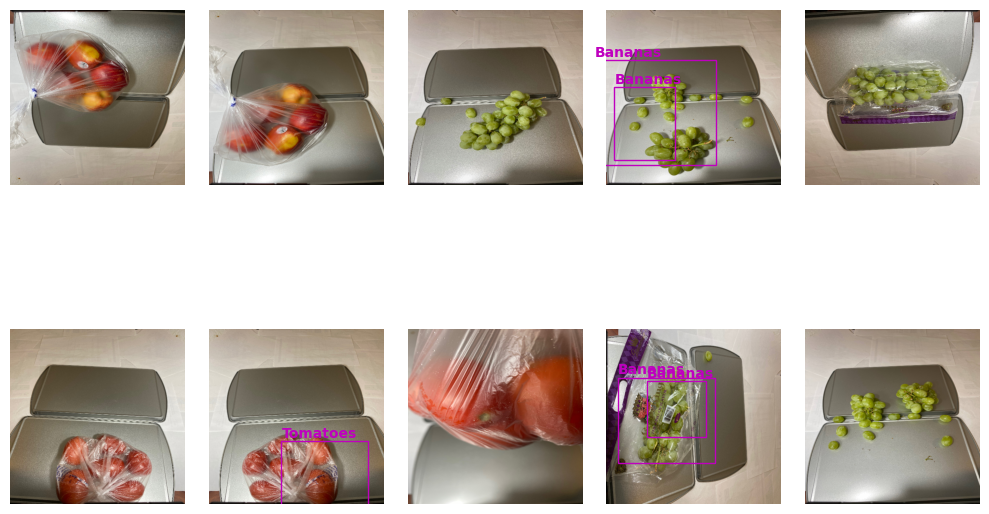

In [147]:
pred_decoded = decode_prediction_nms(pred, threshold=0.5)
visualize(batch["image"], pred_decoded)

In [ ]:
# ПОСЧИТАТЬ МЕТРИКИ

Оценка на тесте: 100%|██████████| 45/45 [01:15<00:00,  1.67s/it]


Test Loss: 5.317721221358687


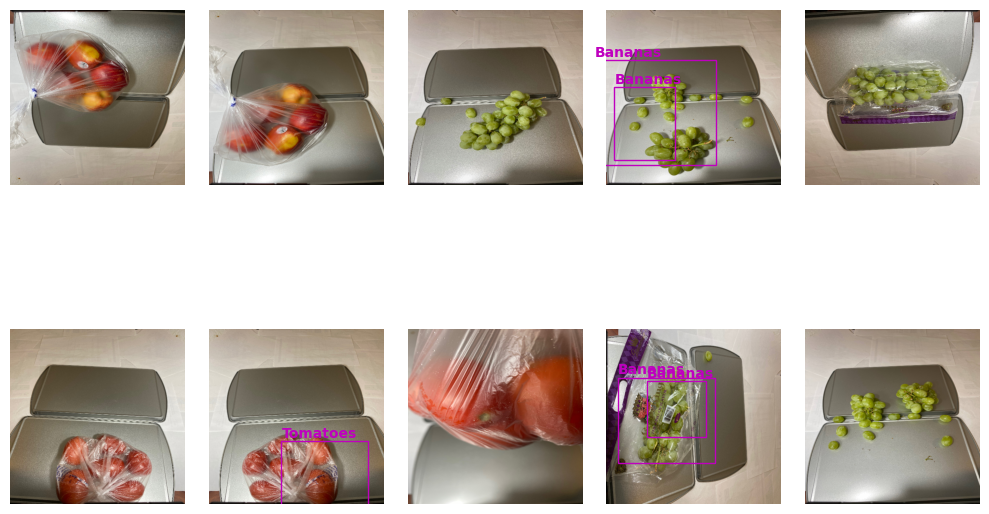

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


exp1_test/test_loss,▁
exp1_test/test_loss,5.31772


In [162]:
test_loader = torch.utils.data.DataLoader(test_ds, 10, collate_fn=collate_fn, shuffle=False)

model_test_1.eval()
total_loss = 0
num_batches = 0
    
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Оценка на тесте"):
        images = batch["image"].to(device)
        targets = batch["target"].to(device)
            
        pred = model_test_1(images)
            
        batch_loss = 0
        for i in range(pred.shape[0]):
            batch_loss += special_loss(pred[i], targets[i], C=C)
            
        total_loss += batch_loss.item() / pred.shape[0]
        num_batches += 1
    
test_loss = total_loss / num_batches if num_batches > 0 else 0
print("Test Loss:", test_loss)

batch = next(iter(test_loader))
images = batch["image"].to(device)
        
with torch.no_grad():
    pred = model_test_1(images).cpu()
        
pred_decoded = decode_prediction_nms(pred, threshold=0.5)
        
visualize(batch["image"], pred_decoded)
        
wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY, name="exp1_test_evaluation", reinit=True)
wandb.log({"exp1_test/test_loss": test_loss})

wandb.finish()

## Эксперимент 2

Проведем эксперимент с другой моделью, в этот раз возьмем слои от ResNet50, обучим исходные слои с меньшим шагом, а новые - с большим

In [106]:
class Detector(nn.Module):
    def __init__(self, C):
        super().__init__()
        model = torchvision.models.resnet50(weights=ResNet50_Weights.DEFAULT)
        self.rn = nn.Sequential(*list(model.children())[:-2])

        self.vgg = nn.Sequential(
           nn.Conv2d(in_channels=2048, out_channels=512, kernel_size=3, padding=1),
           nn.BatchNorm2d(num_features=512),
           nn.ReLU(),

           nn.Conv2d(in_channels=512, out_channels=128, kernel_size=3, padding=1),
           nn.BatchNorm2d(num_features=128),
           nn.ReLU(),

           nn.Conv2d(in_channels=128, out_channels=32, kernel_size=3, padding=1),
           nn.BatchNorm2d(num_features=32),
           nn.ReLU(),

           nn.Conv2d(in_channels=32, out_channels=5+C, kernel_size=3, padding=1),
           nn.BatchNorm2d(num_features=5+C),
           nn.Sigmoid(),
           
        )

    def forward(self, img):
        x = self.rn(img)
        x = self.vgg(x)
        return x

In [107]:
loader = torch.utils.data.DataLoader(train_ds, 10, collate_fn=collate_fn, shuffle=True)

In [108]:
try:
    if torch.cuda.is_available():
        device = torch.device("cuda")
    elif torch.mps.is_available():
        device =torch.device("mps")
    else:
        device = torch.device("cpu")
except AttributeError:
    device = torch.device("cpu")

device

device(type='cpu')

Обучаем модельку

In [109]:
LR_BACKBONE=1e-5
LR_HEAD=1e-3
EPOCHS = 1
BATCH_SIZE = 1

config={
        "model": "Detector",
        "backbone": "ResNet50",
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "lr_backbone": LR_BACKBONE,
        "lr_head": LR_HEAD,
        "seed": 21,
        "loss": "special_loss",
        "task": "detection",
}

run = wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY, name="cnn_detector_model_test_2", config=config)

In [110]:
torch.manual_seed(21)
model_test_2 = Detector(C).to(device)



opt = torch.optim.Adam([
    {'params': model_test_2.rn.parameters(), 'lr': LR_BACKBONE},   
    {'params': model_test_2.vgg.parameters(), 'lr': LR_HEAD},
])


for e in tqdm(range(1, EPOCHS+1), desc=f"Epoch:"):
    epoch_losses = []

    for batch in tqdm(loader, desc=f"Epoch {e}", position=1, leave=False):
      batch_loss = 0
      images = batch["image"].to(device)
      targets = batch["target"].to(device)
      opt.zero_grad()
      pred = model_test_2(images)

      for el in range(pred.shape[0]):
            batch_loss += special_loss(pred[el], targets[el], C=C)

      batch_loss /= pred.shape[0]
      batch_loss.backward()
      opt.step()
      epoch_losses.append(batch_loss.item())


    mean_train_loss = np.mean(epoch_losses)

    print(f"Epoch {e} done; Train loss {mean_train_loss:.3f};")    

    wandb.log({"epoch": e, "train/loss": mean_train_loss})

Epoch:: 100%|██████████| 1/1 [45:27<00:00, 2727.51s/it]

Epoch 1 done; Train loss 19.431;


In [112]:
os.makedirs("models", exist_ok=True)

In [113]:
pickle.dump(model_test_2, open("models/model_test_2.pkl", 'wb'))

In [114]:
artifact = wandb.Artifact(name="model_test_2", type="model",description="Тест логгирования модели Алины")

artifact.add_file("models/model_test_2.pkl")
run.log_artifact(artifact)

<Artifact model_test_2>

In [115]:
wandb.finish()

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁
train/loss,▁
epoch,1
train/loss,19.43078


In [ ]:
with open('model_test_2.pkl', 'rb') as file:
    model_test_2 = pickle.load(file)

In [ ]:
test_loader = torch.utils.data.DataLoader(test_ds, 10, collate_fn=collate_fn)
i = iter(test_loader)
batch = next(i)

In [ ]:
model_test_2.eval()
pred = model_test_2(batch["image"].to(device)).cpu()


In [ ]:
pred_decoded = decode_prediction_nms(pred, threshold=0.85)
visualize(batch["image"], pred_decoded)

In [ ]:
print(batch_loss.item())

Оценка на тесте: 100%|██████████| 45/45 [03:04<00:00,  4.10s/it]


Test Loss: 17.127475310902533


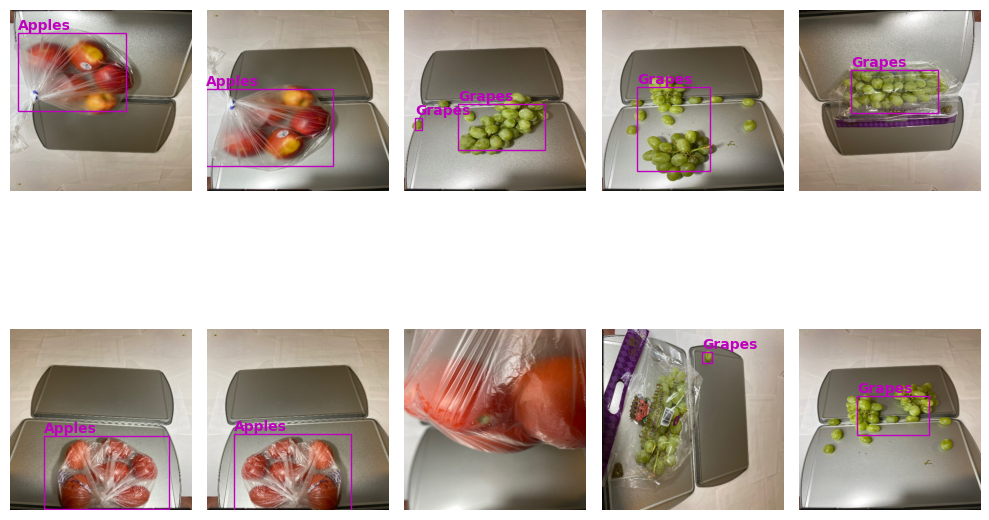

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


exp2_test/test_loss,▁
exp2_test/test_loss,17.12748


In [163]:
test_loader = torch.utils.data.DataLoader(test_ds, 10, collate_fn=collate_fn, shuffle=False)

model_test_2.eval()
total_loss = 0
num_batches = 0
    
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Оценка на тесте"):
        images = batch["image"].to(device)
        targets = batch["target"].to(device)
            
        pred = model_test_2(images)
            
        batch_loss = 0
        for i in range(pred.shape[0]):
            batch_loss += special_loss(pred[i], targets[i], C=C)
            
        total_loss += batch_loss.item() / pred.shape[0]
        num_batches += 1
    
test_loss = total_loss / num_batches if num_batches > 0 else 0
print("Test Loss:", test_loss)
batch = next(iter(test_loader))
images = batch["image"].to(device)
        
with torch.no_grad():
    pred = model_test_2(images).cpu()   
pred_decoded = decode_prediction_nms(pred, threshold=0.85)

visualize(batch["image"], pred_decoded)

wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY, name="exp2_test_evaluation", reinit=True)
wandb.log({"exp2_test/test_loss": test_loss})

wandb.finish()

## ПРОВЕСТИ ЭКСПЕРИМЕНТ С ПОЛНОЦЕННОЙ YOLO

ВОТ ЭТО ЗАГОТОВКА ДЛЯ ПОДСЧЕТА MAP

In [150]:
!pip install torchmetrics

     ------------------------------------ 983.4/983.4 kB 272.0 kB/s eta 0:00:00



[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [148]:
def decode_prediction_modified(pred, upsample=32, threshold=0.7):
    decoded = decode_prediction_nms(pred, upsample=upsample, threshold=threshold)
    results = []
    for bbox in decoded:
        if len(bbox) == 0:
            results.append({
                "boxes": torch.zeros((0,4), dtype=torch.float32),
                "scores": torch.zeros((0,), dtype=torch.float32),
                "labels": torch.zeros((0,), dtype=torch.int64)
            })
            continue

        bbox = torch.tensor(bbox, dtype=torch.float32)
        results.append({"boxes": bbox[:, :4], "scores": bbox[:, 4], "labels": bbox[:, 5].long()})

    return results


In [152]:
def convert_to_yolo_format(data_loader, output_dir, split_name):
    images_dir = os.path.join(output_dir, split_name, 'images')
    labels_dir = os.path.join(output_dir, split_name, 'labels')
    os.makedirs(images_dir, exist_ok=True)
    os.makedirs(labels_dir, exist_ok=True)
    
    for idx, batch in enumerate(tqdm(data_loader, desc=f"Converting {split_name}")):
        images = batch["image"]
        targets = batch["target"]
        
        for i in range(images.shape[0]):
            img = images[i].permute(1, 2, 0).numpy()
            img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
            img = (img * 255).astype(np.uint8)
            img = Image.fromarray(img)
            
            img_name = f"{split_name}_{idx}_{i}.jpg"
            img_path = os.path.join(images_dir, img_name)
            img.save(img_path)
            
            target = targets[i]  
            mask = target[4] == 1  
            
            if mask.sum() > 0:
                h, w = target.shape[1], target.shape[2]
                img_h, img_w = 512, 512
                ds_h = img_h // h
                ds_w = img_w // w
                
                with open(os.path.join(labels_dir, img_name.replace('.jpg', '.txt')), 'w') as f:
                    for cy in range(h):
                        for cx in range(w):
                            if mask[cy, cx]:
                                cx_box = target[0, cy, cx].item()
                                cy_box = target[1, cy, cx].item()
                                w_box = target[2, cy, cx].item()
                                h_box = target[3, cy, cx].item()
                                cls = int(target[5, cy, cx].item())
                                
                                center_x = (cx_box * ds_w + ds_w * cx) / img_w
                                center_y = (cy_box * ds_h + ds_h * cy) / img_h
                                width = w_box
                                height = h_box
                                
                                f.write(f"{cls} {center_x:.6f} {center_y:.6f} {width:.6f} {height:.6f}\n")
    
    return images_dir, labels_dir

yolo_data_dir = "yolo_dataset"
os.makedirs(yolo_data_dir, exist_ok=True)

train_loader_convert = torch.utils.data.DataLoader(train_ds, batch_size=1, collate_fn=collate_fn)
test_loader_convert = torch.utils.data.DataLoader(test_ds, batch_size=1, collate_fn=collate_fn)

convert_to_yolo_format(train_loader_convert, yolo_data_dir, 'train')
convert_to_yolo_format(test_loader_convert, yolo_data_dir, 'val')

Converting val: 100%|██████████| 449/449 [00:41<00:00, 10.84it/s]


('yolo_dataset\\val\\images', 'yolo_dataset\\val\\labels')

In [154]:
import yaml

In [155]:
yolo_config = {
    'path': os.path.abspath(yolo_data_dir),
    'train': 'train/images',
    'val': 'val/images',
    'nc': C, 
    'names': list(class_labels.values())
}

with open(os.path.join(yolo_data_dir, 'data.yaml'), 'w', encoding='utf-8') as f:
    yaml.dump(yolo_config, f, allow_unicode=True)

print(yaml.dump(yolo_config, allow_unicode=True))

names:
- Bananas
- Bananas
- Blackberries
- Raspberries
- Grapes
- Grapes
- Tomatoes
- Tomatoes
- Apples
- Apples
nc: 10
path: c:\Users\Polina\Downloads\гп5\yolo_dataset
train: train/images
val: val/images



In [157]:
from ultralytics import YOLO

EPOCHS = 1

run_yolo = wandb.init(
    project=WANDB_PROJECT, 
    entity=WANDB_ENTITY, 
    name="yolov8_experiment",
    config={
        "model": "yolov8n",
        "epochs": EPOCHS,
        "imgsz": 512,
        "batch": 16,
        "data": "yolo_dataset/data.yaml"
    }
)

model_yolo = YOLO('yolov8n.pt')

results = model_yolo.train(
    data=os.path.join(yolo_data_dir, 'data.yaml'),
    epochs=EPOCHS,
    imgsz=512,
    batch=16,
    device='cpu',  
    workers=0,
    patience=10,
    project='yolo_experiment',
    name='yolov8_fruits',
    exist_ok=True,
    verbose=True,
    seed=21
)

print(f"Лучшая модель: {results.save_dir}/weights/best.pt")

Ultralytics 8.4.64  Python-3.11.0 torch-2.12.0+cpu CPU (AMD Ryzen 7 5800H with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_dataset\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_fruits, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pa

In [158]:
best_model = YOLO(f'{results.save_dir}/weights/best.pt')
metrics = best_model.val(data=os.path.join(yolo_data_dir, 'data.yaml'), split='val')

wandb.log({
    "yolo/mAP50": metrics.box.map50,
    "yolo/mAP50-95": metrics.box.map,
    "yolo/precision": metrics.box.mp,
    "yolo/recall": metrics.box.mr
})

print(f"  mAP@0.5: {metrics.box.map50:.4f}")
print(f"  mAP@0.5:0.95: {metrics.box.map:.4f}")
print(f"  Precision: {metrics.box.mp:.4f}")
print(f"  Recall: {metrics.box.mr:.4f}")

wandb.finish()

Ultralytics 8.4.64  Python-3.11.0 torch-2.12.0+cpu CPU (AMD Ryzen 7 5800H with Radeon Graphics)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 406.894.5 MB/s, size: 37.7 KB)
val: Scanning C:\Users\Polina\Downloads\гп5\yolo_dataset\val\labels.cache... 449 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 449/449  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 1.2it/s 24.7s0.9ss
                   all        449        550       0.73      0.779       0.84      0.644
               Bananas         58         58      0.863          1      0.994      0.824
               Bananas         52         67       0.62          1      0.975      0.825
          Blackberries         23         23      0.495          1      0.898      0.612
           Raspberries         26         26      0.908      0.764      0.924      0.635
                Grap

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


  mAP@0.5: 0.8396
  mAP@0.5:0.95: 0.6442
  Precision: 0.7297
  Recall: 0.7791


yolo/mAP50,▁
yolo/mAP50-95,▁
yolo/precision,▁
yolo/recall,▁
yolo/mAP50,0.8396
yolo/mAP50-95,0.64422
yolo/precision,0.72974
yolo/recall,0.77915


In [165]:
model = YOLO("yolov8n.pt")
results = model.val(
        data="yolo_dataset/data.yaml",
        imgsz=512,
        batch=16,
        device='cpu'
)
 

print(f"  mAP@0.5: {results.box.map50:.4f}")
print(f"  mAP@0.5:0.95: {results.box.map:.4f}")
    
wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY, name="exp3_test", reinit=True)
wandb.log({
        "exp3_test/mAP50": results.box.map50,
        "exp3_test/mAP50_95": results.box.map,
})
wandb.finish()

Ultralytics 8.4.64  Python-3.11.0 torch-2.12.0+cpu CPU (AMD Ryzen 7 5800H with Radeon Graphics)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access  (ping: 0.20.1 ms, read: 96.013.7 MB/s, size: 36.8 KB)
val: Scanning C:\Users\Polina\Downloads\гп5\yolo_dataset\val\labels.cache... 449 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 449/449  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 1.0it/s 28.4s1.0ss
                   all        449        550     0.0133     0.0659    0.00185   0.000707
                person         58         58     0.0212      0.293    0.00641    0.00351
               bicycle         52         67          0          0          0          0
                   car         23         23     0.0107      0.174    0.00338   0.000733
            motorcycle         26         26     0.0417     0.0769    0.00395   0.000763
              airpl

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


exp3_test/mAP50,▁
exp3_test/mAP50_95,▁
exp3_test/mAP50,0.00185
exp3_test/mAP50_95,0.00071
